In [1]:
import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.datasets import make_spd_matrix
from sklearn.covariance import graphical_lasso, GraphicalLasso, GraphicalLassoCV
from tqdm.notebook import tqdm

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from scipy.stats import chi2

from numpy.lib.stride_tricks import sliding_window_view

from statsmodels.stats.multitest import fdrcorrection

%matplotlib inline

# fix random seed
np.random.seed(39)

In [2]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, tol=1e-8):
    return np.all(np.abs(a-a.T) < tol)

In [3]:
def gradient_descent_step(coeffs_zero, H_s, C, M, alpha):
    coeffs_new = np.zeros(coeffs_zero.shape)
    psi_hat = (coeffs_zero.reshape(-1, 1, 1)*H_s).sum(0)
    diff = 0
    for h in range(M):
        grad_log_l_h = np.trace(inv(psi_hat).dot(H_s[h])) - np.trace(H_s[h].dot(C))
        diff += np.abs(alpha*grad_log_l_h)
        coeffs_new[h] = coeffs_zero[h] + alpha*grad_log_l_h
        
    return coeffs_new, diff

def gradient_descent(coeffs_zero, H_s, C, M, alpha=0.01, iters=15):
    coeffs_imo = coeffs_zero
    for i in range(iters):
        #print(coeffs_imo)
        coeffs_imo, diff = gradient_descent_step(coeffs_imo, H_s, C, M, alpha=alpha)
        #print(diff)
        if diff < 1e-8:
            break
    #print(coeffs_imo)
    
    return coeffs_imo

def gradient_descent_step_single(coeffs_zero, H_s, C, M, alpha, N, to_change=None):
    coeffs_new = np.zeros(coeffs_zero.shape)
    psi_hat = (coeffs_zero.reshape(-1, 1, 1)*H_s).sum(0)
    inv_psi_hat = inv(psi_hat)
    diff = 0
    for h in range(M):
        if to_change == None or to_change == h:
            grad_log_l_h = np.trace(inv_psi_hat.dot(H_s[h])) - np.trace(H_s[h].dot(C))
            #grad_log_l_h = grad_log_l_h*(N/2)
            diff += np.abs(alpha*grad_log_l_h)
            coeffs_new[h] = coeffs_zero[h] + alpha*grad_log_l_h
        else:
            coeffs_new[h] = coeffs_zero[h]
        
    return coeffs_new, diff

def gradient_descent_single(coeffs_zero, H_s, C, M, N, dim, alpha=0.01, iters=15, to_change=None):
    coeffs_imo = coeffs_zero
    best_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
    best_coeffs = coeffs_imo.copy()
    for i in range(iters):
        #print(coeffs_imo)
        coeffs_imo, diff = gradient_descent_step_single(coeffs_imo, H_s, C, M, alpha=alpha, 
                                                        N=N, to_change=to_change)
        new_likelihood = calc_likelihood_precision(coeffs_imo, H_s, C, N=N, P=dim)
        better = False
        if new_likelihood > best_likelihood:
            best_likelihood = new_likelihood
            best_coeffs = coeffs_imo.copy()
            better = True
        #print(diff, better, best_coeffs, coeffs_imo)
    #print(coeffs_imo)
    
    return best_coeffs

def calc_matrices_precision(psi_hat, H_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_psi_hat = inv(psi_hat) # calculate psi_hat inverse
    for g in range(dim):
        for h in range(dim):
            mult = ((inv_psi_hat.dot(H_s[g])).dot(inv_psi_hat)).dot(H_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs
        rhs = np.trace(inv_psi_hat.dot(H_s[g])) - np.trace(C.dot(H_s[g]))
        B[g] = rhs
        
    return A, B

def iterative_soln_precision(coeffs_zero, H_s, C, dim, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo + t_i
        #print(s_i)
        s_imo = s_i
        
    return s_imo

def iterative_soln_precision_single(coeffs_zero, H_s, C, dim, modify_index=0, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo.copy()
        s_i[modify_index] = s_imo[modify_index] + t_i[modify_index]
        #print(s_i)
        s_imo = s_i
        
    return s_imo

def unbiased_init_precision(C, H_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(H_s[g].dot(H_s[h]))
        B[g] = np.trace(inv(C).dot(H_s[g]))
    return inv(A).dot(B)

def calc_likelihood_precision(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(np.dot(precision_hat, C))
    
    return log_l*(N/2)

def generate_matrices(prec_coeffs=None, M=2, dim=4):
    H_s = []
    if not prec_coeffs:
        prec_coeffs = np.random.rand(M)
    precision = np.zeros((dim, dim))
    H_s_stacked = np.zeros((dim**2, M))
    for i in range(M):
        mat = make_spd_matrix(dim)
        H_s.append(mat)
        precision += prec_coeffs[i]*mat
        H_s_stacked[:, i] = mat.flatten()
    H_s = np.array(H_s)
    
    # ensure basis matrices are linearly independent
    assert np.linalg.matrix_rank(H_s_stacked) == M, "Not Linearly Independent basis matrices"
    
    # ensure it's actually symmetric
    # minimal modification on scale of 1e-15
    precision_corrected = (precision + precision.T)/2
    
    return H_s, precision_corrected, prec_coeffs

def generate_matrices_orthogonal(prec_coeffs=None, M=2, dim=4):
    H_s = []
    if not prec_coeffs:
        prec_coeffs = np.random.rand(M)
    precision = np.zeros((dim, dim))
    H_s_stacked = np.zeros((dim**2, M))
    mat = make_spd_matrix(dim)
    indxes = np.random.choice(np.arange(dim), (M, dim//M), replace=False)
    for i in range(M):
        A = np.zeros((dim, dim))
        for idx in indxes[i]:
            for idx2 in indxes[i]:
                A[idx, idx2] = mat[idx, idx2]
        H_s.append(A)
        precision += prec_coeffs[i]*A
        H_s_stacked[:, i] = A.flatten()
    H_s = np.array(H_s)
    
    # ensure basis matrices are linearly independent
    assert np.linalg.matrix_rank(H_s_stacked) == M, "Not Linearly Independent basis matrices"
    
    # ensure it's actually symmetric
    # minimal modification on scale of 1e-15
    precision_corrected = (precision + precision.T)/2
    
    return H_s, precision_corrected, prec_coeffs

def collect_precision_matrix(H_s, prec_coeffs):
    precision = (prec_coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    
    return precision

def sim_data(covar, dim, N=1000):
    assert is_symmetric(covar), is_pos_def(covar)
    data_sim = np.random.multivariate_normal(np.zeros(dim), covar, N).T
    data_sim = data_sim - data_sim.mean()
    C = np.cov(data_sim)
    
    return data_sim, C

def likelihood_ratio_test(likelihood_null, likelihood_alternative, dof):
    delta_d = -2*(likelihood_null-likelihood_alternative)
    
    return delta_d, chi2.pdf(delta_d, dof)

def cluster_precision(precision):
    dist_mat = np.abs(precision).max() - np.abs(precision)
    np.fill_diagonal(dist_mat, 0)
    assert is_symmetric(dist_mat), is_pos_def(dist_mat)
    
    #pairwise_distances = sch.distance.pdist(precision_one)
    pairwise_distances = squareform(dist_mat)
    Z = linkage(pairwise_distances,
                method='average'  # dissimilarity metric: max distance across all pairs of 
                                   # records between two clusters
        )

    # calculate full dendrogram and visualize it
    plt.figure(figsize=(10, 5))
    dendrogram(
                Z,
                orientation='right',
                labels=np.arange(dim),
                distance_sort='descending',
                show_leaf_counts=False
              )
    plt.show()
    
    return Z

def sim_changepoint_mv_normal_simple(M=2, dim=4, N=500):
    H_s, precision_one, prec_coeffs_one = generate_matrices(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    prec_coeffs_two = prec_coeffs_one.copy()
    prec_coeffs_two[0] += 0.2
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    
    return H_s, data_total

def sim_changepoint_mv_normal_orthogonal(M=2, dim=4, N=500):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    prec_coeffs_two = prec_coeffs_one.copy()
    prec_coeffs_two[0] += 0.2
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    
    return H_s, data_total

def sim_changepoint_mv_normal_orthogonal_mult_coeff(M=2, dim=4, N=500, num_coeffs_change=1):
    assert dim % M == 0, "Need dim divisible by M for sake of sampling at the moment"
    H_s, precision_one, prec_coeffs_one = generate_matrices_orthogonal(M=M, dim=dim)
    data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)
    
    assert num_coeffs_change <= M, "Cannot change more coefficients than exist"
    
    # multiple coeffs to change - sample them randomly
    to_change_coeffs = np.random.choice(np.arange(M), num_coeffs_change, replace=False)
    prec_coeffs_two = prec_coeffs_one.copy()
    for i in range(num_coeffs_change):
        prec_coeffs_two[to_change_coeffs[i]] += np.random.uniform(0.1, 0.3, 1)[0]
        
    precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
    data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)
    
    data_total = np.concatenate((data_one, data_two), axis=1)
    C_total = np.cov(data_total)
    print("Precision Coefficients Pre-Changepoint: ", prec_coeffs_one)
    print("Precision Coefficients Post-Changepoint: ", prec_coeffs_two)
    
    return H_s, data_total

def LRT_all_coeffs_second_order(data_total, M, dim, N, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)

        s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
        s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)

        coeffs_hat_one = iterative_soln_precision(s_zero_one, H_s, C_one, dim=M, iters=iters)
        coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=iters)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
            
        test_stat, p_val = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
        lrt_vals.append(test_stat)
        p_vals.append(p_val)
    return lrt_vals, p_vals    

def LRT_individual_coeffs_second_order(data_total, M, dim, N, window_size=500, iters=15):
    lrt_vals = []
    p_vals = []
    for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
        start_win_indx = i
        first_end_indx = i+window_size
        last_end_indx = i+2*window_size
        data_one = data_total[:, i:i+window_size]
        data_two = data_total[:, i+window_size:i+2*window_size]
        data_full = np.concatenate((data_one, data_two), axis=1)
        C_one = np.cov(data_one)
        C_two = np.cov(data_two)
        C_full = np.cov(data_full)

        s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=iters)
        
        # null likelihood
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                               N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        
        test_stats_m = []
        p_vals_m = []
        # iterate over each coefficient
        for i in range(M):
            alpha_i_change_pre = iterative_soln_precision_single(coeffs_hat_total, H_s, C_one, dim=M, 
                                                                   modify_index=i, iters=iters)
            alpha_i_change_post = iterative_soln_precision_single(coeffs_hat_total, H_s, C_two, dim=M, 
                                                                    modify_index=i, iters=iters)
            # likelihood on pre data, alpha_one change
            alt_likelihood_alpha_i_pre = calc_likelihood_precision(coeffs=alpha_i_change_pre, H_s=H_s, C=C_one, 
                                                                     N=data_one.shape[1], P=dim)
            # likelihood on post data, alpha_one change
            alt_likelihood_alpha_i_post = calc_likelihood_precision(coeffs=alpha_i_change_post, H_s=H_s, C=C_two, 
                                                                      N=data_two.shape[1], P=dim)
            # total likelihood alt first coeff
            alt_likelihood_alpha_i = alt_likelihood_alpha_i_pre + alt_likelihood_alpha_i_post
            
            test_stat_i, p_val_i = first_test = likelihood_ratio_test(null_likelihood, 
                                                                      alt_likelihood_alpha_i, 2)
            test_stats_m.append(test_stat_i)
            p_vals_m.append(p_val_i)
            
        lrt_vals.append(test_stats_m)
        p_vals.append(p_vals_m)
    
    # return arrays with shape (num_tests, M)
    return np.array(lrt_vals), np.array(p_vals)

def apply_fdr_correction(p_vals_all, alpha=0.05):
    corrected_p_vals_all = []
    for i in range(p_vals_all.shape[0]):
        rejected, corrected_p_vals_i = fdrcorrection(p_vals_all[i], alpha=alpha)
        corrected_p_vals_all.append(corrected_p_vals_i)
    return np.array(corrected_p_vals_all)

In [6]:
M = 2
dim = 16
N = 1500
window_size = 500
#H_s, data_total = sim_changepoint_mv_normal_simple(M=M, dim=dim, N=N)
#H_s, data_total = sim_changepoint_mv_normal_orthogonal(M=M, dim=dim, N=N)
H_s, data_total = sim_changepoint_mv_normal_orthogonal_mult_coeff(M=M, dim=dim, N=N, num_coeffs_change=1)
data_total.shape

Precision Coefficients Pre-Changepoint:  [0.5230324  0.32969375]
Precision Coefficients Post-Changepoint:  [0.80313953 0.32969375]


(16, 3000)

In [7]:
"""
Note: running optimization can take awhile in higher dimensions, due to inverting high dim matrices (I think)
"""

lrt_vals, p_vals = LRT_all_coeffs_second_order(data_total, M=M, dim=dim, N=N, window_size=window_size)

  0%|          | 0/2000 [00:00<?, ?it/s]

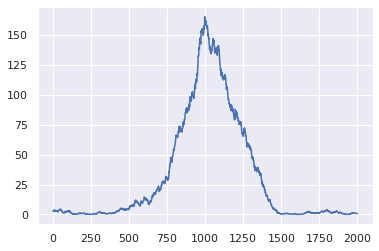

In [8]:
plt.plot(lrt_vals)

In [9]:
lrt_vals_all, p_vals_all = LRT_individual_coeffs_second_order(data_total, M=M, dim=dim, N=N, window_size=window_size)

  0%|          | 0/2000 [00:00<?, ?it/s]

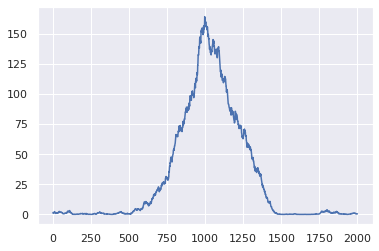

In [10]:
plt.plot(lrt_vals_all[:, 0])

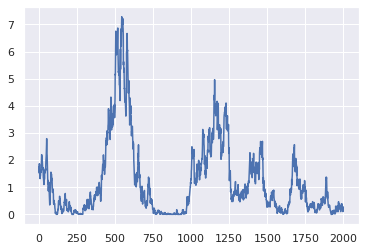

In [11]:
plt.plot(lrt_vals_all[:, 1])

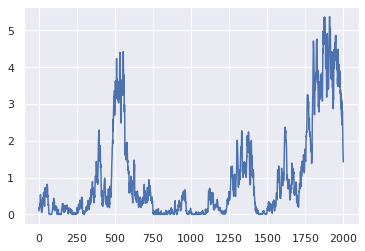

In [119]:
plt.plot(lrt_vals_all[:, 2])

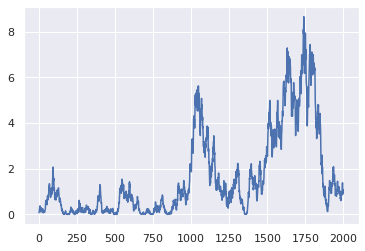

In [120]:
plt.plot(lrt_vals_all[:, 3])

In [121]:
corrected_p_vals_all = apply_fdr_correction(p_vals_all)

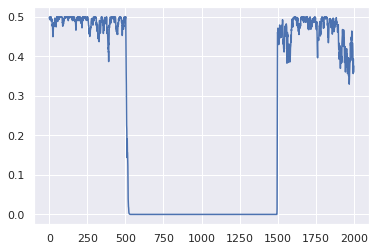

In [122]:
plt.plot(corrected_p_vals_all[:, 0])

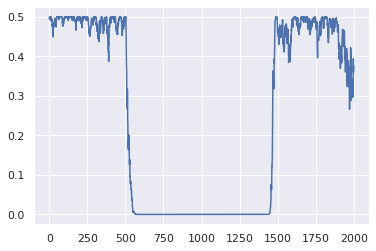

In [123]:
plt.plot(corrected_p_vals_all[:, 1])

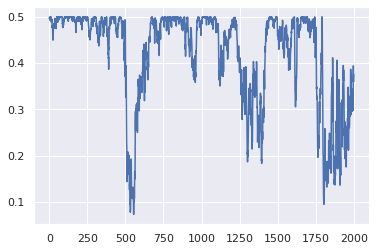

In [124]:
plt.plot(corrected_p_vals_all[:, 2])

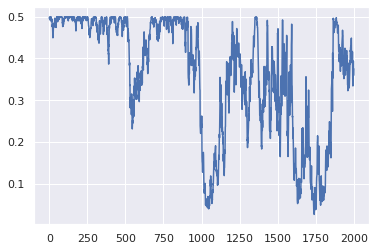

In [125]:
plt.plot(corrected_p_vals_all[:, 3])

  0%|          | 0/2000 [00:00<?, ?it/s]

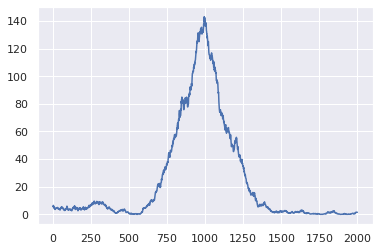

In [19]:
"""
First order solver

Full LRT - not individual coeffs
"""

use_unbiased_init = False

lrt_vals = []
p_vals = []
for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
    start_win_indx = i
    first_end_indx = i+window_size
    last_end_indx = i+2*window_size
    data_one = data_total[:, i:i+window_size]
    data_two = data_total[:, i+window_size:i+2*window_size]
    data_full = np.concatenate((data_one, data_two), axis=1)
    C_one = np.cov(data_one)
    C_two = np.cov(data_two)
    C_full = np.cov(data_full)
    
    s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
    s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
    s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
    
    if not use_unbiased_init:
        coeffs_hat_one = gradient_descent_single(s_zero_one, H_s, C_one, M=M, N=data_one.shape[1], 
                                                 dim=dim, alpha=0.01, 
                                                 iters=45, to_change=None)
        coeffs_hat_two = gradient_descent_single(s_zero_two, H_s, C_two, M=M, N=data_two.shape[1], 
                                                 dim=dim, alpha=0.01, 
                                                 iters=45, to_change=None)
        coeffs_hat_total = gradient_descent_single(s_zero_total, H_s, C_full, M=M, N=data_full.shape[1], 
                                                   dim=dim, alpha=0.01, 
                                                   iters=45, to_change=None)
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
    else:
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                                N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=s_zero_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=s_zero_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
    lrt_tuple = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
    lrt_vals.append(lrt_tuple[0])
    p_vals.append(lrt_tuple[1])
plt.plot(lrt_vals)

  0%|          | 0/2000 [00:00<?, ?it/s]

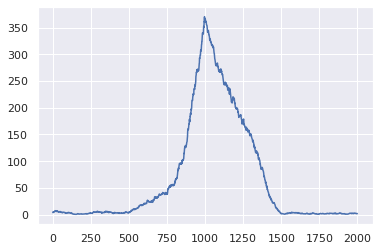

In [28]:
"""
Second order solver

Full LRT - not individual coeffs
"""


use_unbiased_init = False

lrt_vals = []
p_vals = []
for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
    start_win_indx = i
    first_end_indx = i+window_size
    last_end_indx = i+2*window_size
    data_one = data_total[:, i:i+window_size]
    data_two = data_total[:, i+window_size:i+2*window_size]
    data_full = np.concatenate((data_one, data_two), axis=1)
    C_one = np.cov(data_one)
    C_two = np.cov(data_two)
    C_full = np.cov(data_full)
    
    s_zero_one = unbiased_init_precision(C_one, H_s, N=data_one.shape[1], dim=M)
    s_zero_two = unbiased_init_precision(C_two, H_s, N=data_two.shape[1], dim=M)
    s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
    
    if not use_unbiased_init:
        coeffs_hat_one = iterative_soln_precision(s_zero_one, H_s, C_one, dim=M, iters=15)
        coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=15)
        coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=15)
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
    else:
        null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
        null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
        null_likelihood = null_first + null_second
        alt_likelihood_one = calc_likelihood_precision(coeffs=s_zero_one, H_s=H_s, C=C_one,
                                                       N=data_one.shape[1], P=dim)
        alt_likelihood_two = calc_likelihood_precision(coeffs=s_zero_two, H_s=H_s, C=C_two, 
                                                      N=data_two.shape[1], P=dim)
    lrt_tuple = likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)
    lrt_vals.append(lrt_tuple[0])
    p_vals.append(lrt_tuple[1])
plt.plot(lrt_vals)

In [21]:
"""
First order solver

Individual LRT
"""

lrt_vals_one = []
lrt_vals_two = []
for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
    start_win_indx = i
    first_end_indx = i+window_size
    last_end_indx = i+2*window_size
    data_one = data_total[:, i:i+window_size]
    data_two = data_total[:, i+window_size:i+2*window_size]
    data_full = np.concatenate((data_one, data_two), axis=1)
    C_one = np.cov(data_one)
    C_two = np.cov(data_two)
    C_full = np.cov(data_full)
    
    s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
    ########
    coeffs_hat_total = gradient_descent_single(s_zero_total, H_s, C_full, M=M, N=data_full.shape[1], 
                                               dim=dim, alpha=0.01, 
                                               iters=45, to_change=None)
    # refit null model, modifying first coefficient, first half of data
    alpha_one_change_pre = gradient_descent_single(coeffs_hat_total, H_s, C_one, M=M, N=data_one.shape[1], 
                                                   dim=dim, alpha=0.01, 
                                                   iters=45, to_change=0)
    # refit null model, modifying first coefficient, second half of data
    alpha_one_change_post = gradient_descent_single(coeffs_hat_total, H_s, C_two, M=M, N=data_two.shape[1],
                                                    dim=dim, alpha=0.01, 
                                                    iters=45, to_change=0)
    # refit null model, modifying second coefficient, first half of data
    alpha_two_change_pre = gradient_descent_single(coeffs_hat_total, H_s, C_one, M=M, N=data_one.shape[1], 
                                                   dim=dim, alpha=0.01, 
                                                   iters=45, to_change=1)
    # refit null model, modifying second coefficient, second half of data
    alpha_two_change_post = gradient_descent_single(coeffs_hat_total, H_s, C_two, M=M, N=data_two.shape[1],
                                                    dim=dim, alpha=0.01, 
                                                    iters=45, to_change=1)
    # likelihood on pre data, alpha_one change
    alt_likelihood_alpha_one_pre = calc_likelihood_precision(coeffs=alpha_one_change_pre, H_s=H_s, C=C_one, 
                                                             N=data_one.shape[1], P=dim)
    # likelihood on post data, alpha_one change
    alt_likelihood_alpha_one_post = calc_likelihood_precision(coeffs=alpha_one_change_post, H_s=H_s, C=C_two, 
                                                              N=data_two.shape[1], P=dim)
    # total likelihood alt first coeff
    alt_likelihood_alpha_one = alt_likelihood_alpha_one_pre + alt_likelihood_alpha_one_post

    # likelihood on pre data, alpha_two change
    alt_likelihood_alpha_two_pre = calc_likelihood_precision(coeffs=alpha_two_change_pre, H_s=H_s, C=C_one, 
                                                             N=data_one.shape[1], P=dim)
    # likelihood on post data, alpha_two change
    alt_likelihood_alpha_two_post = calc_likelihood_precision(coeffs=alpha_two_change_post, H_s=H_s, C=C_two, 
                                                              N=data_two.shape[1], P=dim)
    # total likelihood alt second coeff
    alt_likelihood_alpha_two = alt_likelihood_alpha_two_pre + alt_likelihood_alpha_two_post
    # null likelihood
    null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
    null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
    null_likelihood = null_first + null_second

    # two dof? I think so...
    first_test = likelihood_ratio_test(null_likelihood, 
                                       alt_likelihood_alpha_one, 2)
    second_test = likelihood_ratio_test(null_likelihood,
                                        alt_likelihood_alpha_two, 2)
    lrt_vals_one.append(first_test[0])
    lrt_vals_two.append(second_test[0])

  0%|          | 0/2000 [00:00<?, ?it/s]

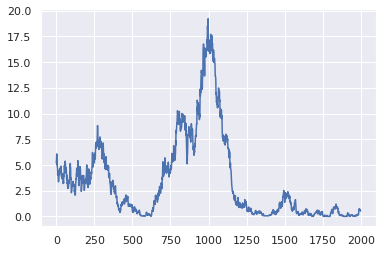

In [22]:
plt.plot(lrt_vals_one)

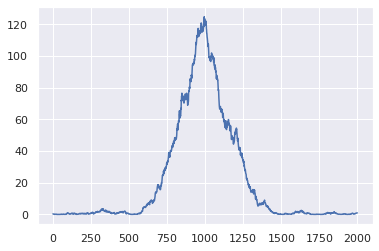

In [23]:
plt.plot(lrt_vals_two)

In [29]:
"""
Second order solver

Individual LRT
"""

lrt_vals_one = []
lrt_vals_two = []
for i in tqdm(range(0, data_total.shape[1]-2*window_size, 1)):
    start_win_indx = i
    first_end_indx = i+window_size
    last_end_indx = i+2*window_size
    data_one = data_total[:, i:i+window_size]
    data_two = data_total[:, i+window_size:i+2*window_size]
    data_full = np.concatenate((data_one, data_two), axis=1)
    C_one = np.cov(data_one)
    C_two = np.cov(data_two)
    C_full = np.cov(data_full)
    
    s_zero_total = unbiased_init_precision(C_full, H_s, N=data_full.shape[1], dim=M)
    ########
    coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_full, dim=M, iters=15)
    # refit null model, modifying first coefficient, first half of data
    alpha_one_change_pre = iterative_soln_precision_single(coeffs_hat_total, H_s, C_one, dim=M, 
                                                           modify_index=0, iters=15)
    # refit null model, modifying first coefficient, second half of data
    alpha_one_change_post = iterative_soln_precision_single(coeffs_hat_total, H_s, C_two, dim=M, 
                                                            modify_index=0, iters=15)
    # refit null model, modifying second coefficient, first half of data
    alpha_two_change_pre = iterative_soln_precision_single(coeffs_hat_total, H_s, C_one, dim=M, 
                                                           modify_index=1, iters=15)
    # refit null model, modifying second coefficient, second half of data
    alpha_two_change_post = iterative_soln_precision_single(coeffs_hat_total, H_s, C_two, dim=M, 
                                                            modify_index=1, iters=15)
    # likelihood on pre data, alpha_one change
    alt_likelihood_alpha_one_pre = calc_likelihood_precision(coeffs=alpha_one_change_pre, H_s=H_s, C=C_one, 
                                                             N=data_one.shape[1], P=dim)
    # likelihood on post data, alpha_one change
    alt_likelihood_alpha_one_post = calc_likelihood_precision(coeffs=alpha_one_change_post, H_s=H_s, C=C_two, 
                                                              N=data_two.shape[1], P=dim)
    # total likelihood alt first coeff
    alt_likelihood_alpha_one = alt_likelihood_alpha_one_pre + alt_likelihood_alpha_one_post

    # likelihood on pre data, alpha_two change
    alt_likelihood_alpha_two_pre = calc_likelihood_precision(coeffs=alpha_two_change_pre, H_s=H_s, C=C_one, 
                                                             N=data_one.shape[1], P=dim)
    # likelihood on post data, alpha_two change
    alt_likelihood_alpha_two_post = calc_likelihood_precision(coeffs=alpha_two_change_post, H_s=H_s, C=C_two, 
                                                              N=data_two.shape[1], P=dim)
    # total likelihood alt second coeff
    alt_likelihood_alpha_two = alt_likelihood_alpha_two_pre + alt_likelihood_alpha_two_post
    # null likelihood
    null_first = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, 
                                           N=data_one.shape[1], P=dim)
    null_second = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, 
                                            N=data_two.shape[1], P=dim)
    null_likelihood = null_first + null_second

    # two dof? I think so...
    first_test = likelihood_ratio_test(null_likelihood, 
                                       alt_likelihood_alpha_one, 2)
    second_test = likelihood_ratio_test(null_likelihood,
                                        alt_likelihood_alpha_two, 2)
    lrt_vals_one.append(first_test[0])
    lrt_vals_two.append(second_test[0])

  0%|          | 0/2000 [00:00<?, ?it/s]

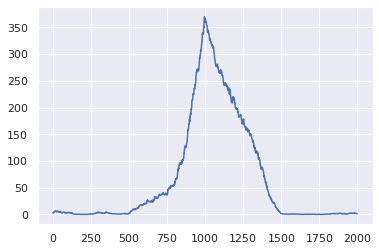

In [30]:
plt.plot(lrt_vals_one)

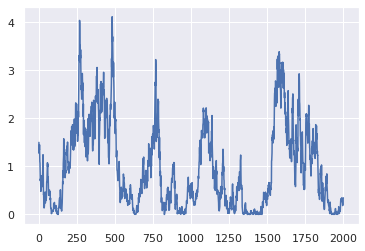

In [31]:
plt.plot(lrt_vals_two)

In [ ]:
M = 2
dim = 4
N = 1000

H_s, precision_one, prec_coeffs_one = generate_matrices(M=M, dim=dim)
data_one, C_one = sim_data(covar=inv(precision_one), dim=dim, N=N)

In [ ]:
s_zero_one = unbiased_init_precision(C_one, H_s, N=N, dim=M)
coeffs_hat_one = iterative_soln_precision(s_zero_one, H_s, C_one, dim=M, iters=5)
coeffs_hat_one, prec_coeffs_one

In [ ]:
coeffs_hat_one_gd = gradient_descent(s_zero_one, H_s, C_one, M=M, alpha=0.01, iters=5000)
s_zero_one, coeffs_hat_one_gd, prec_coeffs_one

In [ ]:
coeffs_hat_one_gd = gradient_descent_single(s_zero_one, H_s, C_one, M=M, N=N, dim=dim, alpha=0.0001, 
                                            iters=5000, to_change=0)
s_zero_one, coeffs_hat_one_gd, prec_coeffs_one

In [ ]:
prec_coeffs_two = prec_coeffs_one.copy()
prec_coeffs_two[0] += 0.2
precision_two = collect_precision_matrix(H_s, prec_coeffs_two)
data_two, C_two = sim_data(covar=inv(precision_two), dim=dim, N=N)

In [ ]:
s_zero_two = unbiased_init_precision(C_two, H_s, N=N, dim=M)
coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=10)
coeffs_hat_two, prec_coeffs_two

In [ ]:
data_total = np.concatenate((data_one, data_two), axis=1)
C_total = np.cov(data_total)
s_zero_total = unbiased_init_precision(C_total, H_s, N=N, dim=M)
coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C_total, dim=M, iters=10)
coeffs_hat_total

In [ ]:
coeffs_hat_total, prec_coeffs_one, prec_coeffs_two

In [ ]:
"""
LRT Using total data to fit null model

Fit two models in denominator
"""

# covariance from total data/model - sample size 2*N
null_likelihood = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_total, 
                                            N=2*N, P=dim)
# covariance from first data, total model
alt_likelihood_one = calc_likelihood_precision(coeffs=coeffs_hat_one, H_s=H_s, C=C_one,
                                               N=N, P=dim)
# covariance from second model, second data
alt_likelihood_two = calc_likelihood_precision(coeffs=coeffs_hat_two, H_s=H_s, C=C_two, 
                                              N=N, P=dim)

likelihood_ratio_test(null_likelihood, alt_likelihood_one+alt_likelihood_two, M)

In [ ]:
"""
Refit model on first data, second data using TOTAL model's init, first order iterative

Run two LRT - one for each coefficient change
    (EACH coefficient change pre and post changepoint)
"""
# covariance from total data/model - sample size 2*N
null_likelihood = calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_total, 
                                            N=2*N, P=dim)
# refit null model, modifying first coefficient, first half of data
alpha_one_change_pre = gradient_descent_single(coeffs_hat_total, H_s, C_one, M=M, N=N, dim=dim, alpha=0.0001, 
                                               iters=5000, to_change=0)
# refit null model, modifying first coefficient, second half of data
alpha_one_change_post = gradient_descent_single(coeffs_hat_total, H_s, C_two, M=M, N=N, dim=dim, alpha=0.0001, 
                                               iters=5000, to_change=0)
# refit null model, modifying second coefficient, first half of data
alpha_two_change_pre = gradient_descent_single(coeffs_hat_total, H_s, C_one, M=M, N=N, dim=dim, alpha=0.0001, 
                                               iters=5000, to_change=1)
# refit null model, modifying second coefficient, second half of data
alpha_two_change_post = gradient_descent_single(coeffs_hat_total, H_s, C_two, M=M, N=N, dim=dim, alpha=0.000524921311, 
                                               iters=5000, to_change=1)
# likelihood on pre data, alpha_one change
alt_likelihood_alpha_one_pre = calc_likelihood_precision(coeffs=alpha_one_change_pre, H_s=H_s, C=C_one, N=N, P=dim)
# likelihood on post data, alpha_one change
alt_likelihood_alpha_one_post = calc_likelihood_precision(coeffs=alpha_one_change_post, H_s=H_s, C=C_two, N=N, P=dim)
# total likelihood alt first coeff
alt_likelihood_alpha_one = alt_likelihood_alpha_one_pre + alt_likelihood_alpha_one_post

# likelihood on pre data, alpha_two change
alt_likelihood_alpha_two_pre = calc_likelihood_precision(coeffs=alpha_two_change_pre, H_s=H_s, C=C_one, N=N, P=dim)
# likelihood on post data, alpha_two change
alt_likelihood_alpha_two_post = calc_likelihood_precision(coeffs=alpha_two_change_post, H_s=H_s, C=C_two, N=N, P=dim)
# total likelihood alt second coeff
alt_likelihood_alpha_two = alt_likelihood_alpha_two_pre + alt_likelihood_alpha_two_post


# two dof? I think so...
first_test = likelihood_ratio_test(null_likelihood, 
                                   alt_likelihood_alpha_one, 2)
second_test = likelihood_ratio_test(null_likelihood,
                                   alt_likelihood_alpha_two, 2)
first_test, second_test

In [ ]:
coeffs_hat_total, alpha_one_change_pre, alpha_one_change_post

In [ ]:
coeffs_hat_total, alpha_two_change_pre, alpha_two_change_post

In [ ]:
prec_coeffs_one, prec_coeffs_two

In [ ]:
null_likelihood

In [ ]:
alt_likelihood_alpha_one

In [ ]:
alt_likelihood_alpha_two

In [ ]:
alt_likelihood_alpha_one_pre, alt_likelihood_alpha_one_post

In [ ]:
alt_likelihood_alpha_two_pre, alt_likelihood_alpha_two_post

In [ ]:
calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_one, N=N, P=dim)

In [ ]:
calc_likelihood_precision(coeffs=coeffs_hat_total, H_s=H_s, C=C_two, N=N, P=dim)